# Tursiops Binary LODO — MLP on Perch embeddings

Two variants of a binary detector for *Tursiops truncatus*, evaluated with
Leave-One-Dataset-Out cross-validation on the raw Perch V2 embeddings.

**Variant A — Tursiops vs background only**  
Training data: Tursiops rows + background rows (no other species).  
Question: how well does a clean binary detector transfer across recording sites?

**Variant B — Tursiops vs everything**  
Training data: Tursiops rows + background rows + all other cetacean species rows.  
Other species are relabelled as background (negative class).  
Question: does enriching the negative class with realistic cetacean confounders
improve cross-site generalisation, or hurt Tursiops recall?

Both variants use the same MLP architecture and training recipe as the existing
`perch_v2_cetacean_safe_lodo` notebook.

**LODO holdouts:** Adriatic_Sea, ALNITAK_CAVANILLES, DRYAD, OLTREMARE  
(all datasets that contain Tursiops rows)

**Key metrics:** ROC-AUC, Average Precision, F1 at best threshold (tuned on val)

## 0. Setup

In [1]:
import os, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    precision_recall_curve,
)
from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {DEVICE}  torch: {torch.__version__}")

device: cuda  torch: 2.5.1+cu121


In [3]:
# ── Paths — same corpus as the existing LODO notebook ────────────────────────
IN_DIR  = Path('/data2/mromaniuc/cet-det/alltogether/full_corpus_together/mlp_runs')
PROJ_IN = Path('/data2/mromaniuc/cet-det/alltogether/full_exploration/dim_red/projector_input')
OUT_DIR = Path('./tursiops_binary_lodo_runs')
OUT_DIR.mkdir(exist_ok=True, parents=True)

META_PATH = IN_DIR / 'meta_all_with_taxonomy.parquet'
X_PATH    = PROJ_IN / 'X_all.npy'

print(f"meta:  {META_PATH}  exists={META_PATH.exists()}")
print(f"X_all: {X_PATH}     exists={X_PATH.exists()}")
print(f"out:   {OUT_DIR.resolve()}")

meta:  /data2/mromaniuc/cet-det/alltogether/full_corpus_together/mlp_runs/meta_all_with_taxonomy.parquet  exists=True
X_all: /data2/mromaniuc/cet-det/alltogether/full_exploration/dim_red/projector_input/X_all.npy     exists=True
out:   /data2/mromaniuc/cet-det/alltogether/full_exploration/lodo_and_seeding/tursiops_binary_lodo_runs


In [4]:
meta_all = pd.read_parquet(META_PATH)
X_all    = np.load(X_PATH, mmap_mode='r')
print(f"meta_all: {len(meta_all):,} rows  cols={len(meta_all.columns)}")
print(f"X_all:    {X_all.shape}  dtype={X_all.dtype}")

assert 'row' in meta_all.columns
assert 'group_key' in meta_all.columns

TARGET_SPECIES = 'Tursiops_truncatus'
SPECIES_TIER   = 'label_t4'   # species-level label column

print(f"\nTursiops rows: {(meta_all[SPECIES_TIER] == TARGET_SPECIES).sum():,}")
print(f"Datasets with Tursiops:")
tt = meta_all[meta_all[SPECIES_TIER] == TARGET_SPECIES]
print(tt['dataset'].value_counts().to_string())

meta_all: 247,630 rows  cols=64
X_all:    (247630, 1536)  dtype=float32

Tursiops rows: 7,250
Datasets with Tursiops:
dataset
DRYAD                 2916
OLTREMARE             2904
Adriatic_Sea           942
FREMANTLE              332
ALNITAK_CAVANILLES      58
MONISH                  28
ECOSS_enhanced          27
WATKINS                 24
ECOSS_testtrain         19


## 1. Build binary labels

**Variant A:** Tursiops rows + background rows only.  
**Variant B:** Tursiops rows + background rows + all other species rows (relabelled as background).

In [5]:
def is_background(row):
    """True if the row is a labelled non-mammal / background / anthropogenic."""
    t1 = row['label_t1']
    t2 = row['label_t2']
    if pd.notna(t1) and t1 == 'non_mammal':
        return True
    if pd.notna(t2) and t2 in ('background', 'anthropogenic'):
        return True
    return False

def is_other_species(row):
    """True if the row is a labelled cetacean species that is NOT Tursiops."""
    t4 = row['label_t4']
    return pd.notna(t4) and t4 != TARGET_SPECIES


# ── Variant A: Tursiops vs clean background ───────────────────────────────────
mask_tt  = meta_all[SPECIES_TIER] == TARGET_SPECIES
mask_bg  = meta_all.apply(is_background, axis=1)

meta_varA = meta_all[mask_tt | mask_bg].copy()
meta_varA['binary_label'] = (meta_varA[SPECIES_TIER] == TARGET_SPECIES).astype(int)
meta_varA = meta_varA.dropna(subset=['group_key'])

print("Variant A — Tursiops vs background only")
print(f"  Total rows: {len(meta_varA):,}")
print(f"  Tursiops:   {meta_varA['binary_label'].sum():,}")
print(f"  Background: {(meta_varA['binary_label']==0).sum():,}")
print(f"  Datasets:   {sorted(meta_varA['dataset'].unique())}")

print()

# ── Variant B: Tursiops vs everything (background + other species) ────────────
mask_other = meta_all.apply(is_other_species, axis=1)

meta_varB = meta_all[mask_tt | mask_bg | mask_other].copy()
meta_varB['binary_label'] = (meta_varB[SPECIES_TIER] == TARGET_SPECIES).astype(int)
meta_varB = meta_varB.dropna(subset=['group_key'])

print("Variant B — Tursiops vs everything")
print(f"  Total rows: {len(meta_varB):,}")
print(f"  Tursiops:   {meta_varB['binary_label'].sum():,}")
print(f"  Negative:   {(meta_varB['binary_label']==0).sum():,}")
print(f"    of which background:     {mask_bg.sum():,}")
print(f"    of which other species:  {mask_other.sum():,}")
print(f"  Datasets:   {sorted(meta_varB['dataset'].unique())}")

Variant A — Tursiops vs background only
  Total rows: 220,856
  Tursiops:   7,250
  Background: 213,606
  Datasets:   ['ALNITAK_CAVANILLES', 'Adriatic_Sea', 'DCLDE_2026', 'DOLPHINFREE', 'DRYAD', 'ECOSS_annot', 'ECOSS_enhanced', 'ECOSS_testtrain', 'FREMANTLE', 'MONISH', 'OLTREMARE', 'WATKINS']

Variant B — Tursiops vs everything
  Total rows: 247,214
  Tursiops:   7,250
  Negative:   239,964
    of which background:     213,606
    of which other species:  26,358
  Datasets:   ['ALNITAK_CAVANILLES', 'Adriatic_Sea', 'DCLDE_2026', 'DOLPHINFREE', 'DRYAD', 'ECOSS_annot', 'ECOSS_enhanced', 'ECOSS_testtrain', 'FREMANTLE', 'MONISH', 'OLTREMARE', 'WATKINS']


In [6]:
# ── LODO holdouts: all datasets containing Tursiops rows ─────────────────────
LODO_HOLDOUTS = sorted(
    meta_all[meta_all[SPECIES_TIER] == TARGET_SPECIES]['dataset'].unique().tolist()
)
print(f"LODO holdouts ({len(LODO_HOLDOUTS)}): {LODO_HOLDOUTS}")
print()
print("Tursiops rows per holdout dataset:")
for ds in LODO_HOLDOUTS:
    n_tt = (meta_all[meta_all['dataset'] == ds][SPECIES_TIER] == TARGET_SPECIES).sum()
    n_bg = mask_bg[meta_all['dataset'] == ds].sum()
    print(f"  {ds:25s}  Tursiops={n_tt:5,}  background={n_bg:5,}")

LODO holdouts (9): ['ALNITAK_CAVANILLES', 'Adriatic_Sea', 'DRYAD', 'ECOSS_enhanced', 'ECOSS_testtrain', 'FREMANTLE', 'MONISH', 'OLTREMARE', 'WATKINS']

Tursiops rows per holdout dataset:
  ALNITAK_CAVANILLES         Tursiops=   58  background=4,348
  Adriatic_Sea               Tursiops=  942  background=  238
  DRYAD                      Tursiops=2,916  background=3,854
  ECOSS_enhanced             Tursiops=   27  background=   25
  ECOSS_testtrain            Tursiops=   19  background=35,917
  FREMANTLE                  Tursiops=  332  background=    0
  MONISH                     Tursiops=   28  background=    0
  OLTREMARE                  Tursiops=2,904  background=13,956
  WATKINS                    Tursiops=   24  background=    0


## 2. MLP + training utilities

Same architecture as the existing LODO notebook: `1536 → 512 → 256 → 1`.  
Binary cross-entropy with `pos_weight` for class imbalance.  
Threshold tuned on the validation set, applied to the test set.

In [7]:
class BinaryMLP(nn.Module):
    def __init__(self, in_dim, hidden=(512, 256), dropout=0.3):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


def train_binary_mlp(Xtr, ytr, Xva, yva,
                     hidden=(512, 256), dropout=0.3,
                     lr=1e-3, weight_decay=1e-4, batch_size=1024,
                     epochs=60, patience=8, verbose=False):
    model = BinaryMLP(Xtr.shape[1], hidden=hidden, dropout=dropout).to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # pos_weight to handle class imbalance
    n_pos = ytr.sum()
    n_neg = len(ytr) - n_pos
    pos_w = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32, device=DEVICE)
    crit  = nn.BCEWithLogitsLoss(pos_weight=pos_w)

    tr_dl = DataLoader(
        TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr.astype(np.float32))),
        batch_size=batch_size, shuffle=True, num_workers=0)
    va_dl = DataLoader(
        TensorDataset(torch.from_numpy(Xva), torch.from_numpy(yva.astype(np.float32))),
        batch_size=batch_size, shuffle=False, num_workers=0)

    best_auc, best_state, bad, history = -1.0, None, 0, []

    for ep in range(1, epochs + 1):
        model.train()
        tr_loss, n = 0.0, 0
        for xb, yb in tr_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
            tr_loss += loss.item() * xb.size(0)
            n += xb.size(0)

        model.eval()
        logits, trues = [], []
        with torch.no_grad():
            for xb, yb in va_dl:
                logits.append(model(xb.to(DEVICE)).cpu().numpy())
                trues.append(yb.numpy())
        logits = np.concatenate(logits)
        trues  = np.concatenate(trues)
        probs  = 1 / (1 + np.exp(-logits))  # sigmoid
        va_auc = roc_auc_score(trues, probs) if len(np.unique(trues)) > 1 else 0.0

        history.append({'epoch': ep, 'train_loss': tr_loss / n, 'val_auc': va_auc})
        if verbose:
            print(f"  ep{ep:02d}  loss={tr_loss/n:.4f}  val_auc={va_auc:.4f}")

        if va_auc > best_auc + 1e-4:
            best_auc   = va_auc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, best_auc


def predict_binary(model, X, batch_size=2048):
    model.eval()
    logits = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            logits.append(model(torch.from_numpy(X[i:i+batch_size]).to(DEVICE)).cpu().numpy())
    logits = np.concatenate(logits)
    return 1 / (1 + np.exp(-logits))  # probabilities


def best_threshold_by_f1(y_true, probs, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 37)
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        f1 = f1_score(y_true, (probs >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


def split_train_val(meta_subset, val_size=0.12, random_state=42):
    gss = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=random_state)
    tr, va = next(gss.split(
        np.zeros(len(meta_subset)),
        groups=meta_subset['group_key'].values
    ))
    return tr, va


print("Utilities defined.")

Utilities defined.


## 3. LODO runner

In [8]:
def run_binary_lodo(held_out, meta_binary, variant_name, verbose=True):
    """
    One LODO fold for a binary Tursiops detector.
    meta_binary must have columns: row, group_key, dataset, binary_label.
    """
    train_meta = meta_binary[meta_binary['dataset'] != held_out].copy()
    test_meta  = meta_binary[meta_binary['dataset'] == held_out].copy()

    n_tt_test = test_meta['binary_label'].sum()
    if n_tt_test == 0:
        print(f"  [{held_out}] 0 Tursiops in test — skipping")
        return None

    if verbose:
        print(f"\n  [{held_out}] train pool: {len(train_meta):,} rows  "
              f"({train_meta['binary_label'].sum():,} Tursiops / "
              f"{(train_meta['binary_label']==0).sum():,} neg)")
        print(f"  [{held_out}] test:        {len(test_meta):,} rows  "
              f"({n_tt_test:,} Tursiops / "
              f"{(test_meta['binary_label']==0).sum():,} neg)  "
              f"prevalence={100*n_tt_test/len(test_meta):.1f}%")

    tr_pos, va_pos = split_train_val(train_meta, val_size=0.12)
    rows_tr = train_meta.iloc[tr_pos]['row'].values
    rows_va = train_meta.iloc[va_pos]['row'].values
    rows_te = test_meta['row'].values

    Xtr = np.asarray(X_all[rows_tr], dtype=np.float32)
    Xva = np.asarray(X_all[rows_va], dtype=np.float32)
    Xte = np.asarray(X_all[rows_te], dtype=np.float32)
    ytr = train_meta.iloc[tr_pos]['binary_label'].values
    yva = train_meta.iloc[va_pos]['binary_label'].values
    yte = test_meta['binary_label'].values

    # Standardise on train
    sc  = StandardScaler().fit(Xtr)
    Xtr = sc.transform(Xtr).astype(np.float32)
    Xva = sc.transform(Xva).astype(np.float32)
    Xte = sc.transform(Xte).astype(np.float32)

    t0 = time.time()
    model, history, best_val_auc = train_binary_mlp(
        Xtr, ytr, Xva, yva, verbose=verbose)
    elapsed = time.time() - t0

    # Val threshold sweep
    val_probs  = predict_binary(model, Xva)
    best_t, _  = best_threshold_by_f1(yva, val_probs)

    # Test metrics
    test_probs  = predict_binary(model, Xte)
    test_auc    = roc_auc_score(yte, test_probs)
    test_ap     = average_precision_score(yte, test_probs)
    test_preds  = (test_probs >= best_t).astype(int)
    test_f1     = f1_score(yte, test_preds, zero_division=0)
    test_recall = float((test_preds[yte == 1] == 1).mean()) if n_tt_test > 0 else 0.0
    test_prec   = float((yte[test_preds == 1] == 1).mean()) if test_preds.sum() > 0 else 0.0

    print(f"  [{held_out}] {variant_name}  "
          f"auc={test_auc:.4f}  ap={test_ap:.4f}  "
          f"f1@{best_t:.2f}={test_f1:.4f}  "
          f"recall={test_recall:.4f}  prec={test_prec:.4f}  "
          f"({elapsed:.1f}s)")

    return {
        'held_out':         held_out,
        'variant':          variant_name,
        'n_train':          len(ytr),
        'n_val':            len(yva),
        'n_test':           len(yte),
        'n_test_tursiops':  int(n_tt_test),
        'test_prevalence':  float(n_tt_test / len(yte)),
        'best_val_auc':     float(best_val_auc),
        'best_threshold':   float(best_t),
        'test_auc':         float(test_auc),
        'test_ap':          float(test_ap),
        'test_f1':          float(test_f1),
        'test_recall':      float(test_recall),
        'test_precision':   float(test_prec),
        'elapsed_s':        float(elapsed),
        'history':          history,
        'training_prevalence': float(ytr.sum() / len(ytr)),
        'train_datasets':   sorted(train_meta['dataset'].unique().tolist()),
    }

print("Runner defined.")

Runner defined.


## 4. Run Variant A — Tursiops vs background only

In [9]:
results_varA = {}

print("=" * 72)
print("  VARIANT A — Tursiops vs background only")
print("=" * 72)

for held_out in LODO_HOLDOUTS:
    r = run_binary_lodo(held_out, meta_varA, variant_name='varA_bg_only', verbose=True)
    if r is not None:
        results_varA[held_out] = r

  VARIANT A — Tursiops vs background only

  [ALNITAK_CAVANILLES] train pool: 216,450 rows  (7,192 Tursiops / 209,258 neg)
  [ALNITAK_CAVANILLES] test:        4,406 rows  (58 Tursiops / 4,348 neg)  prevalence=1.3%
  ep01  loss=0.1842  val_auc=0.9924
  ep02  loss=0.1298  val_auc=0.9909
  ep03  loss=0.1124  val_auc=0.9911
  ep04  loss=0.1066  val_auc=0.9908
  ep05  loss=0.0977  val_auc=0.9905
  ep06  loss=0.0924  val_auc=0.9823
  ep07  loss=0.0875  val_auc=0.9903
  ep08  loss=0.0826  val_auc=0.9873
  ep09  loss=0.0754  val_auc=0.9918
  [ALNITAK_CAVANILLES] varA_bg_only  auc=0.6974  ap=0.0219  f1@0.78=0.0000  recall=0.0000  prec=0.0000  (25.8s)

  [Adriatic_Sea] train pool: 219,676 rows  (6,308 Tursiops / 213,368 neg)
  [Adriatic_Sea] test:        1,180 rows  (942 Tursiops / 238 neg)  prevalence=79.8%
  ep01  loss=0.1947  val_auc=0.9935
  ep02  loss=0.1339  val_auc=0.9947
  ep03  loss=0.1171  val_auc=0.9935
  ep04  loss=0.1066  val_auc=0.9954
  ep05  loss=0.0967  val_auc=0.9953
  ep06  lo

## 5. Run Variant B — Tursiops vs everything

In [10]:
results_varB = {}

print("=" * 72)
print("  VARIANT B — Tursiops vs everything (bg + other species)")
print("=" * 72)

for held_out in LODO_HOLDOUTS:
    r = run_binary_lodo(held_out, meta_varB, variant_name='varB_vs_all', verbose=True)
    if r is not None:
        results_varB[held_out] = r

  VARIANT B — Tursiops vs everything (bg + other species)

  [ALNITAK_CAVANILLES] train pool: 242,428 rows  (7,192 Tursiops / 235,236 neg)
  [ALNITAK_CAVANILLES] test:        4,786 rows  (58 Tursiops / 4,728 neg)  prevalence=1.2%
  ep01  loss=0.1793  val_auc=0.9956
  ep02  loss=0.1173  val_auc=0.9959
  ep03  loss=0.1096  val_auc=0.9956
  ep04  loss=0.1028  val_auc=0.9965
  ep05  loss=0.0946  val_auc=0.9965
  ep06  loss=0.0862  val_auc=0.9966
  ep07  loss=0.0773  val_auc=0.9964
  ep08  loss=0.0746  val_auc=0.9962
  ep09  loss=0.0703  val_auc=0.9967
  ep10  loss=0.0701  val_auc=0.9963
  ep11  loss=0.0657  val_auc=0.9960
  ep12  loss=0.0646  val_auc=0.9963
  ep13  loss=0.0623  val_auc=0.9967
  ep14  loss=0.0555  val_auc=0.9964
  [ALNITAK_CAVANILLES] varB_vs_all  auc=0.6387  ap=0.0165  f1@0.90=0.0000  recall=0.0000  prec=0.0000  (42.1s)

  [Adriatic_Sea] train pool: 246,034 rows  (6,308 Tursiops / 239,726 neg)
  [Adriatic_Sea] test:        1,180 rows  (942 Tursiops / 238 neg)  prevalence=7

## 6. Summary table

In [11]:
rows = []
for ds in LODO_HOLDOUTS:
    for results, vname in [(results_varA, 'varA_bg_only'), (results_varB, 'varB_vs_all')]:
        r = results.get(ds)
        if r is None:
            continue
        rows.append({
            'held_out':          ds,
            'variant':           vname,
            'n_train':           r['n_train'],
            'n_test_tursiops':   r['n_test_tursiops'],
            'test_prevalence':   f"{100*r['test_prevalence']:.1f}%",
            'best_val_auc':      round(r['best_val_auc'], 4),
            'test_auc':          round(r['test_auc'], 4),
            'test_ap':           round(r['test_ap'], 4),
            'test_f1':           round(r['test_f1'], 4),
            'test_recall':       round(r['test_recall'], 4),
            'test_precision':    round(r['test_precision'], 4),
            'threshold':         round(r['best_threshold'], 2),
        })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))
summary_df.to_csv(OUT_DIR / 'tursiops_binary_lodo_summary.csv', index=False)
print(f"\nSaved → {OUT_DIR / 'tursiops_binary_lodo_summary.csv'}")

          held_out      variant  n_train  n_test_tursiops test_prevalence  best_val_auc  test_auc  test_ap  test_f1  test_recall  test_precision  threshold
ALNITAK_CAVANILLES varA_bg_only   190008               58            1.3%        0.9924    0.6974   0.0219   0.0000       0.0000          0.0000       0.78
ALNITAK_CAVANILLES  varB_vs_all   211477               58            1.2%        0.9966    0.6387   0.0165   0.0000       0.0000          0.0000       0.90
      Adriatic_Sea varA_bg_only   195911              942           79.8%        0.9955    0.8426   0.9494   0.4785       0.3185          0.9615       0.92
      Adriatic_Sea  varB_vs_all   219918              942           79.8%        0.9977    0.8292   0.9486   0.3490       0.2123          0.9804       0.95
             DRYAD varA_bg_only   187459             2916           43.1%        0.9945    0.8597   0.8714   0.7550       0.6886          0.8356       0.95
             DRYAD  varB_vs_all   210805             2916       

In [12]:
# ── Pivot: AUC comparison A vs B per holdout ──────────────────────────────────
print("\n── test_auc pivot ──")
pivot_auc = summary_df.pivot(index='held_out', columns='variant', values='test_auc')
pivot_auc['delta (B - A)'] = pivot_auc['varB_vs_all'] - pivot_auc['varA_bg_only']
print(pivot_auc.to_string())

print("\n── test_recall pivot ──")
pivot_rec = summary_df.pivot(index='held_out', columns='variant', values='test_recall')
pivot_rec['delta (B - A)'] = pivot_rec['varB_vs_all'] - pivot_rec['varA_bg_only']
print(pivot_rec.to_string())


── test_auc pivot ──
variant             varA_bg_only  varB_vs_all  delta (B - A)
held_out                                                    
ALNITAK_CAVANILLES        0.6974       0.6387        -0.0587
Adriatic_Sea              0.8426       0.8292        -0.0134
DRYAD                     0.8597       0.8026        -0.0571
ECOSS_enhanced            1.0000       0.9714        -0.0286
ECOSS_testtrain           0.9991       0.9999         0.0008
FREMANTLE                    NaN          NaN            NaN
MONISH                       NaN       0.5938            NaN
OLTREMARE                 0.8869       0.8985         0.0116
WATKINS                      NaN       0.9761            NaN

── test_recall pivot ──
variant             varA_bg_only  varB_vs_all  delta (B - A)
held_out                                                    
ALNITAK_CAVANILLES        0.0000       0.0000         0.0000
Adriatic_Sea              0.3185       0.2123        -0.1062
DRYAD                     0.6886      

## 7. Learning curves

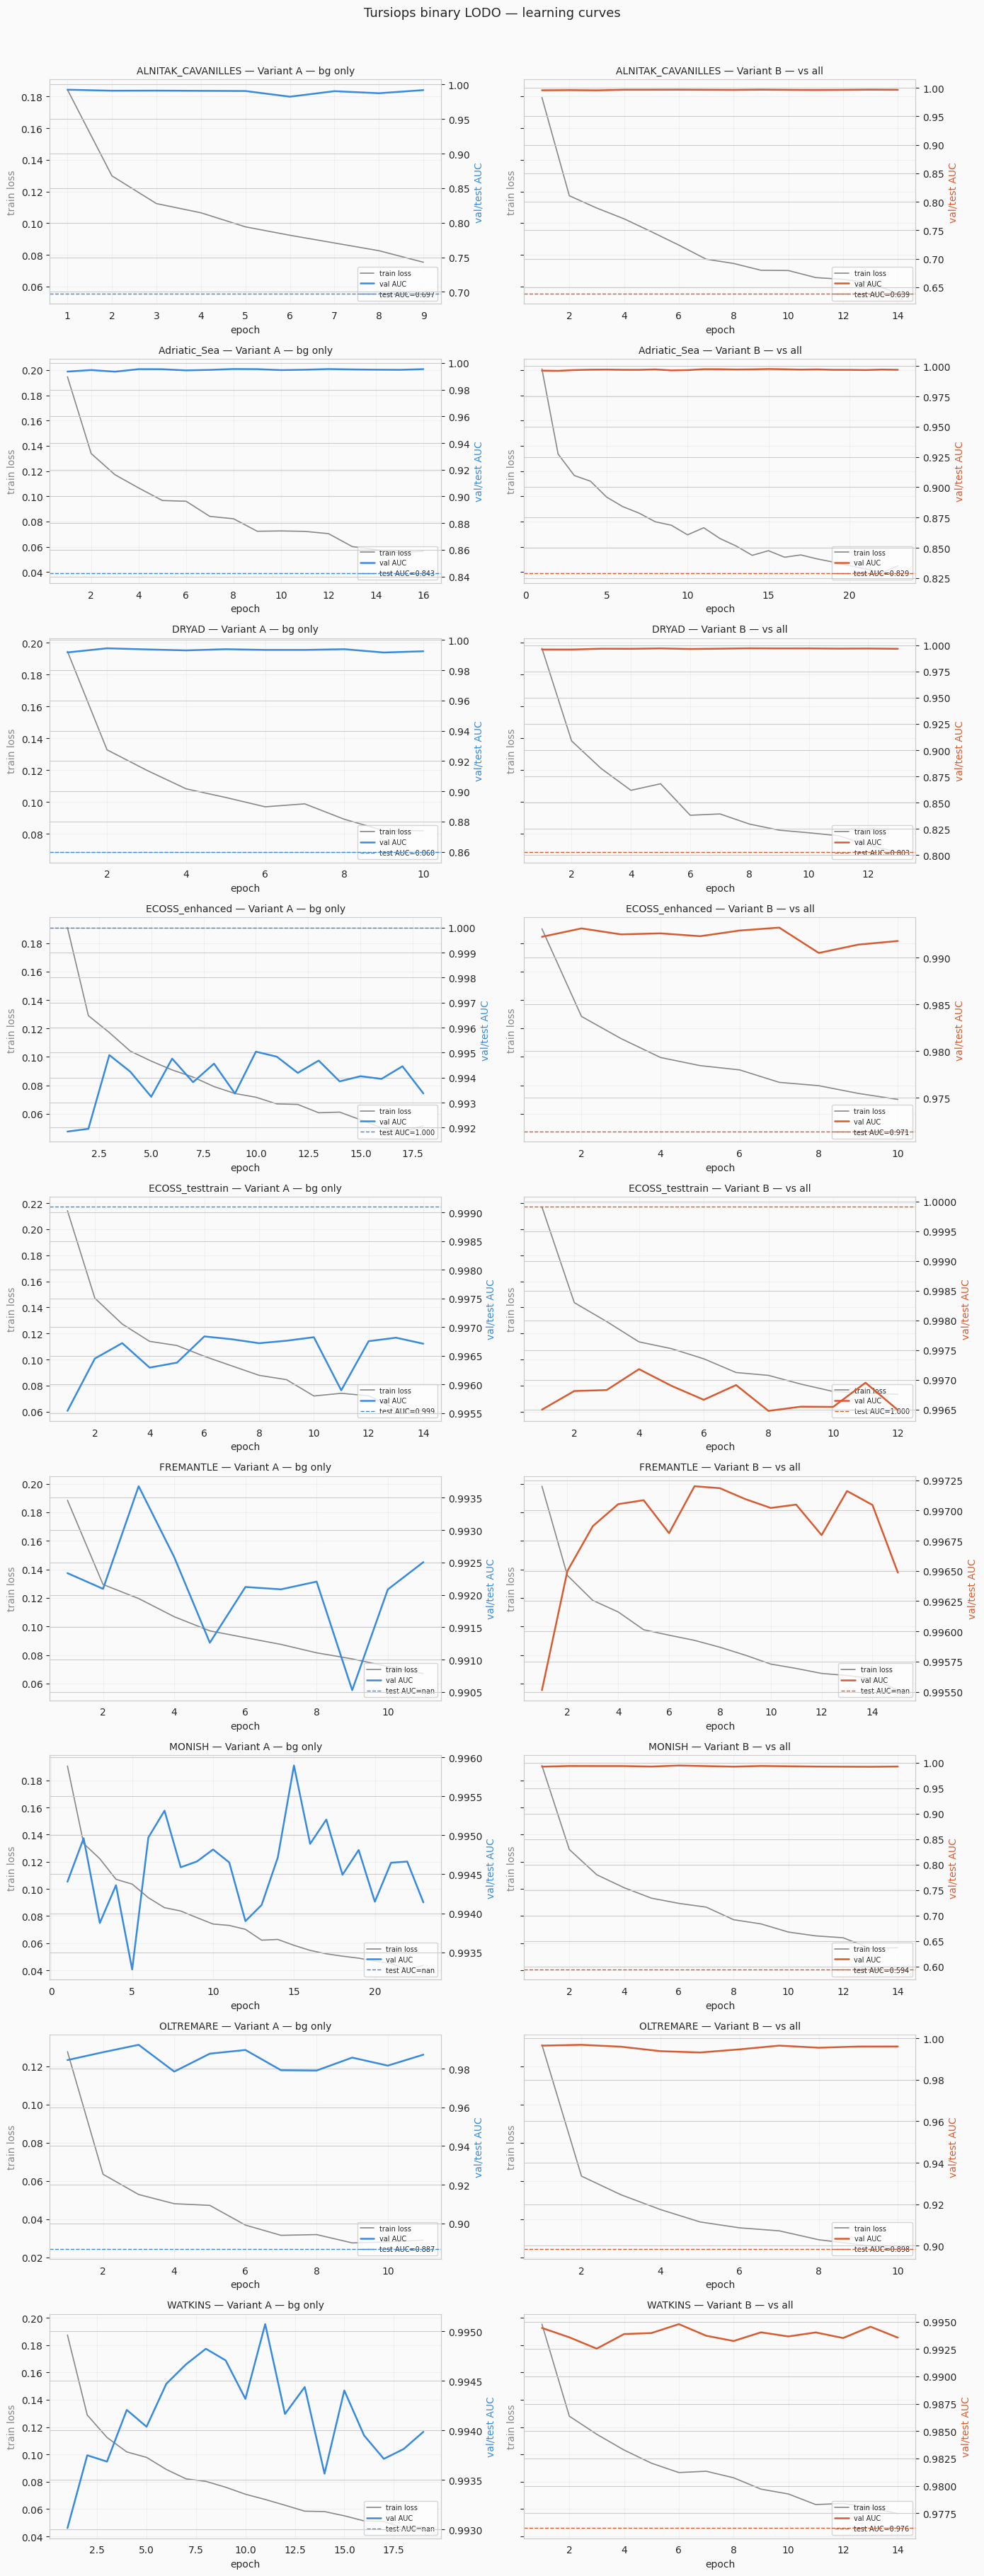

Saved → tursiops_binary_lodo_runs/learning_curves.png


In [13]:
fig, axes = plt.subplots(len(LODO_HOLDOUTS), 2,
                          figsize=(14, 4 * len(LODO_HOLDOUTS)),
                          sharey='row')
fig.patch.set_facecolor('#fafafa')

for row_idx, ds in enumerate(LODO_HOLDOUTS):
    for col_idx, (results, vname, color) in enumerate([
        (results_varA, 'Variant A — bg only', '#378ADD'),
        (results_varB, 'Variant B — vs all',  '#D85A30'),
    ]):
        ax = axes[row_idx, col_idx]
        ax.set_facecolor('#fafafa')
        r  = results.get(ds)
        if r is None:
            ax.set_visible(False)
            continue
        epochs  = [h['epoch']      for h in r['history']]
        val_auc = [h['val_auc']    for h in r['history']]
        tr_loss = [h['train_loss'] for h in r['history']]
        ax2 = ax.twinx()
        ax.plot(epochs, tr_loss, color='#888888', linewidth=1.2, label='train loss')
        ax2.plot(epochs, val_auc, color=color, linewidth=1.8, label='val AUC')
        ax2.axhline(r['test_auc'], color=color, linestyle='--', linewidth=1,
                    label=f"test AUC={r['test_auc']:.3f}")
        ax.set_title(f"{ds} — {vname}", fontsize=10)
        ax.set_xlabel('epoch'); ax.set_ylabel('train loss', color='#888888')
        ax2.set_ylabel('val/test AUC', color=color)
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc='lower right')
        ax.grid(True, alpha=0.2)
        ax.spines['top'].set_visible(False)

plt.suptitle('Tursiops binary LODO — learning curves', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {OUT_DIR / 'learning_curves.png'}")

## 8. Save full results

In [14]:
all_results = {}
for ds, r in results_varA.items():
    all_results[f"{ds}__varA"] = {k: v for k, v in r.items() if k != 'history'}
for ds, r in results_varB.items():
    all_results[f"{ds}__varB"] = {k: v for k, v in r.items() if k != 'history'}

with open(OUT_DIR / 'all_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print(f"Saved → {OUT_DIR / 'all_results.json'}")
print("\nDone.")

Saved → tursiops_binary_lodo_runs/all_results.json

Done.
